### TASK 1 : Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ad_df = pd.read_csv('Advertising.csv')

In [3]:
ad_df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [4]:
ad_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
ad_df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### TASK 2 : Visualize Dataset

<Axes: >

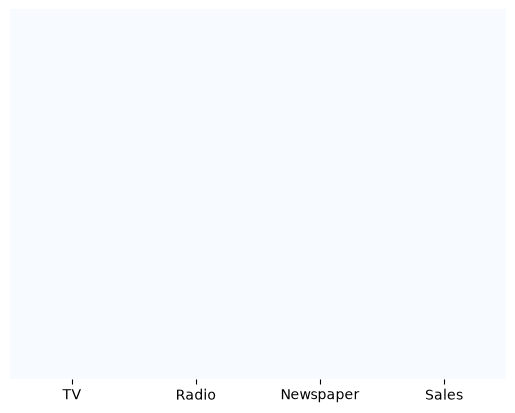

In [6]:
sns.heatmap(ad_df.isnull(), yticklabels= False, cbar = False, cmap = 'Blues')

array([[<Axes: title={'center': 'TV'}>,
        <Axes: title={'center': 'Radio'}>],
       [<Axes: title={'center': 'Newspaper'}>,
        <Axes: title={'center': 'Sales'}>]], dtype=object)

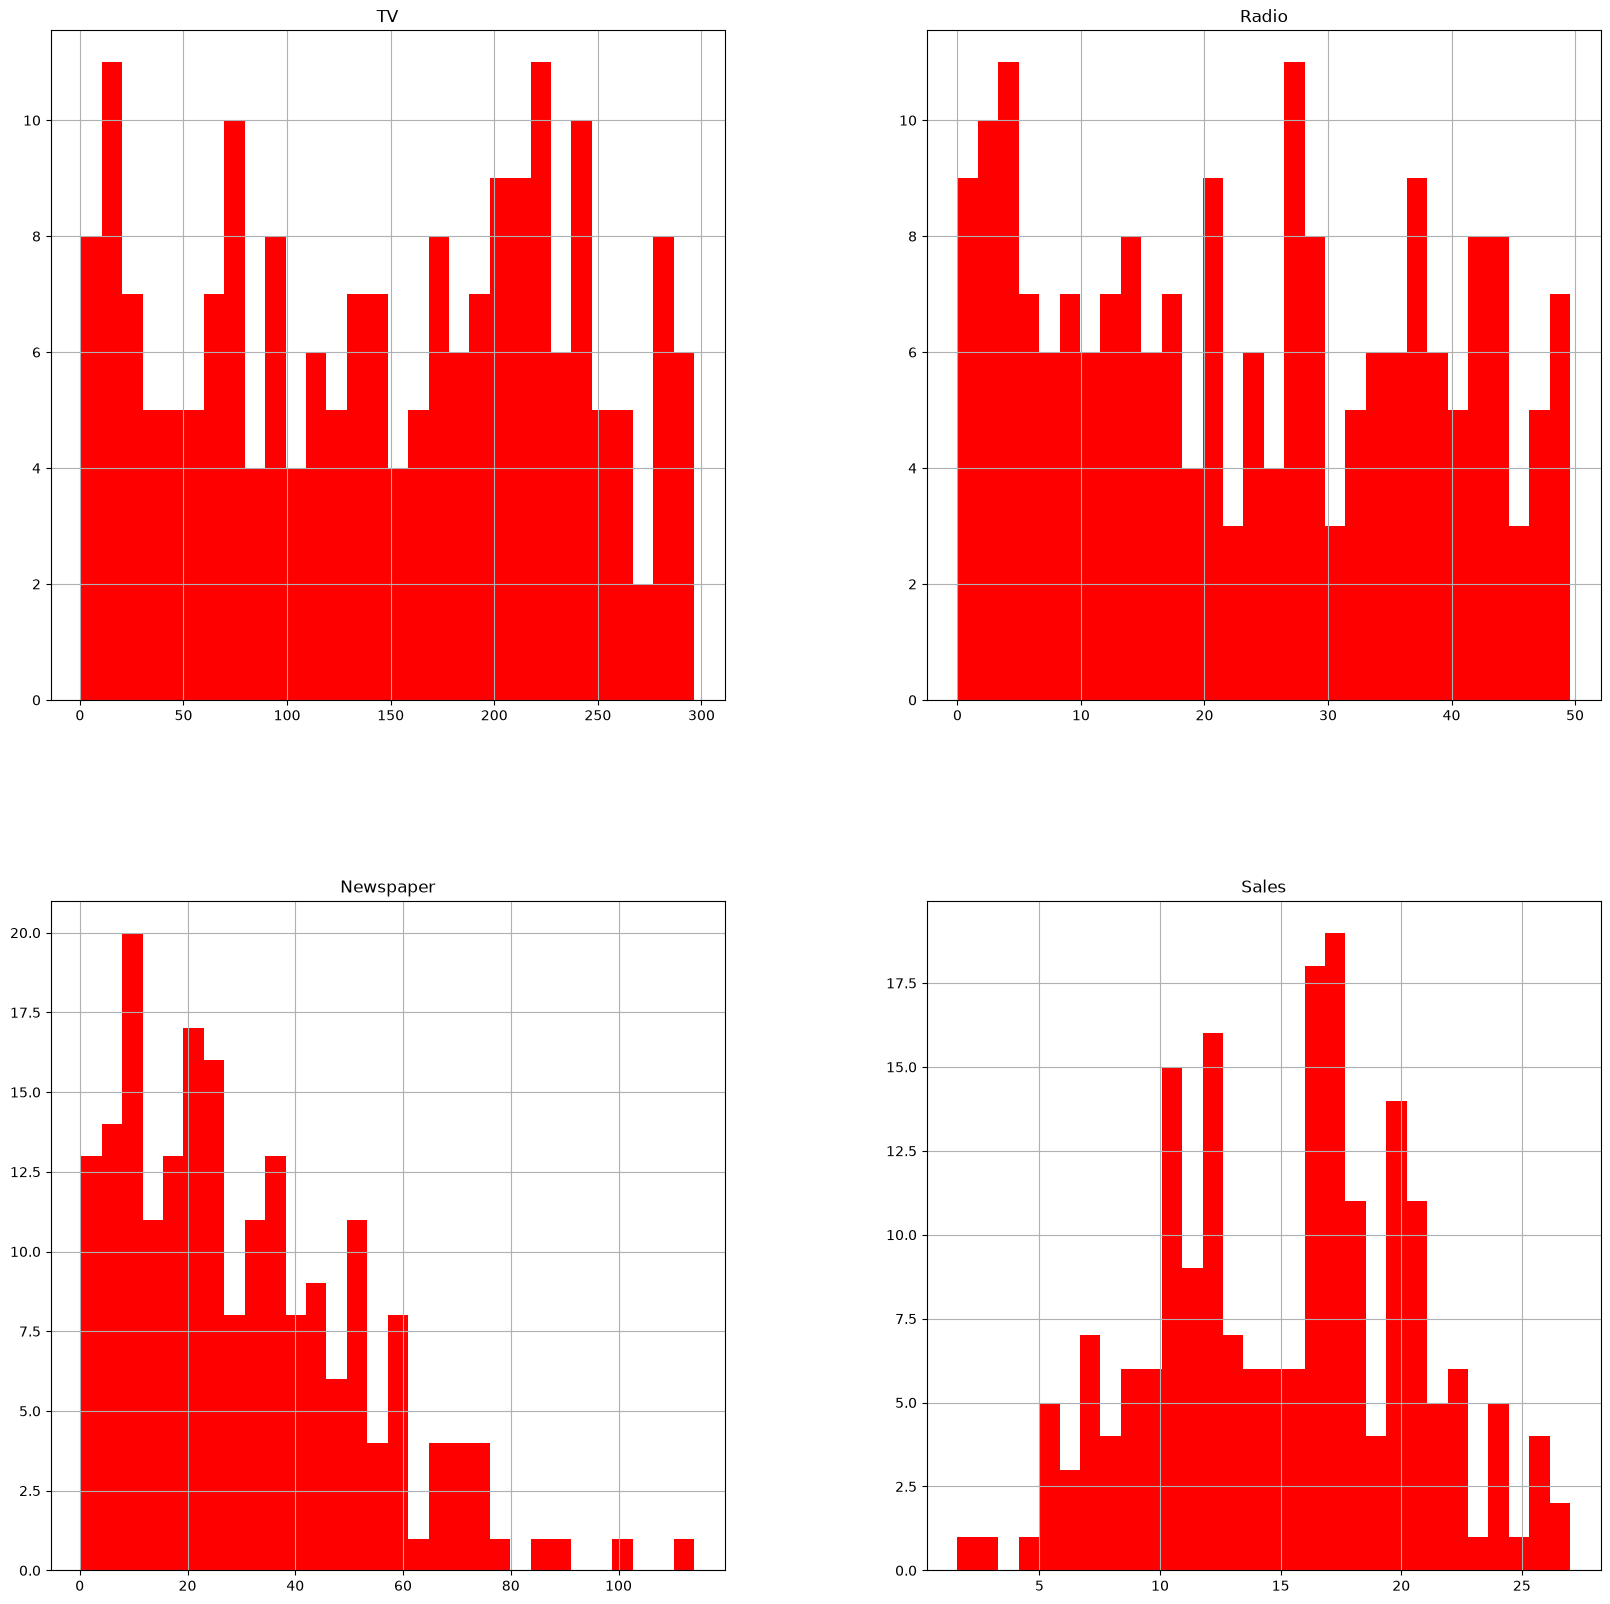

In [7]:
ad_df.hist(bins = 30, figsize = (20, 20), color = 'r')

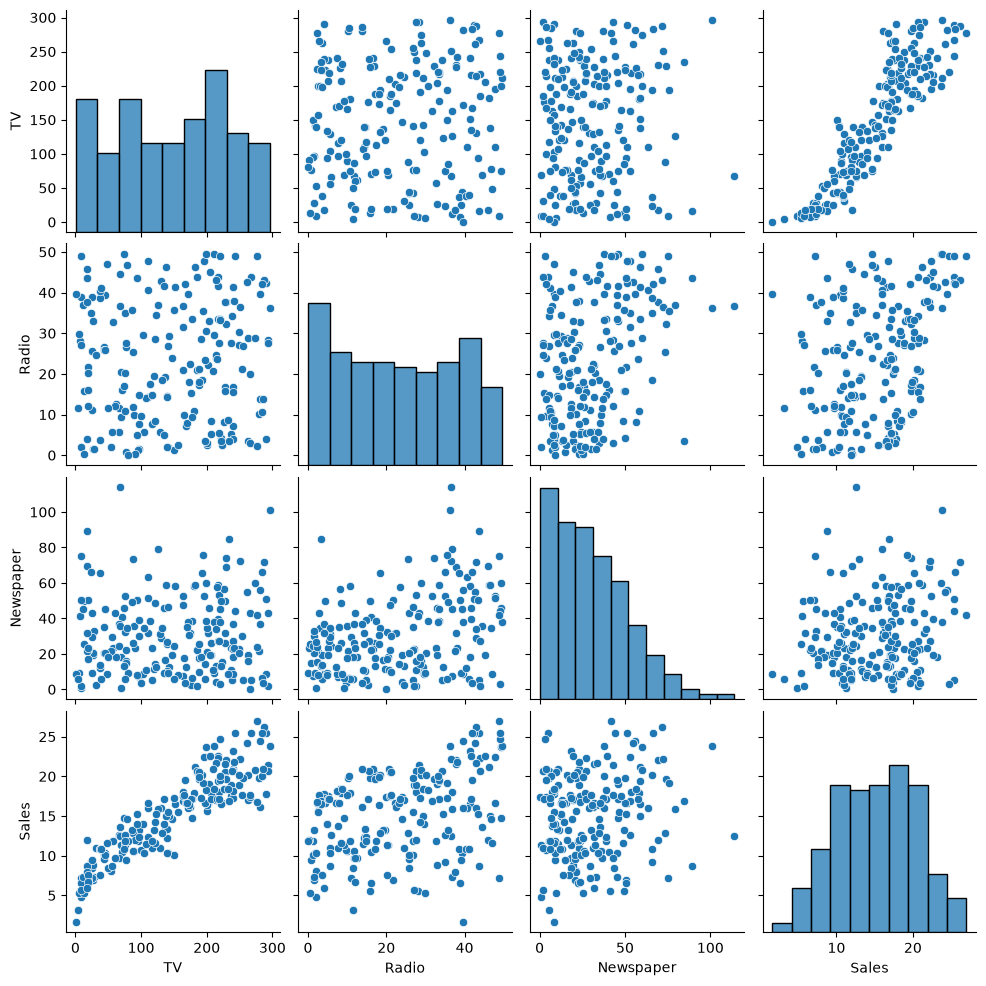

In [8]:
sns.pairplot(ad_df)

<Axes: >

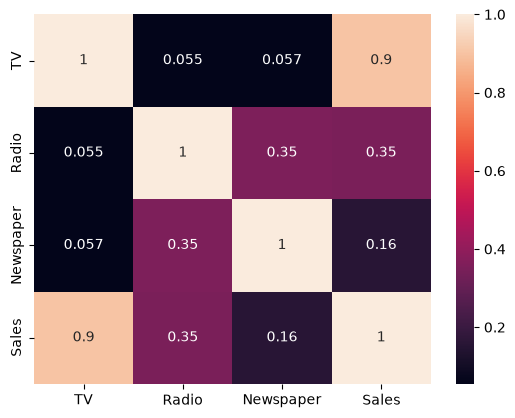

In [9]:
correlations = ad_df.corr()
sns.heatmap(correlations, annot = True)

### TASK 3 : Test & Train Dataset

In [10]:
X = ad_df[['TV', 'Radio', 'Newspaper']]

In [11]:
X.shape

(200, 3)

In [12]:
y = ad_df['Sales']

In [13]:
y.shape

(200,)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

### TASK 4 : Train the Model

In [15]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(fit_intercept = True)

In [16]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05, 0.1 ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.671
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [17]:
print('Linear Model Coeff (m):', regressor.coef_)
print('Linear Model Coeff(b):', regressor.intercept_)

Linear Model Coeff (m): [ 0.05436631  0.10459235 -0.00116573]
Linear Model Coeff(b): 4.671024408281665


### TASK 5 : Evaluate the Model

In [18]:
y_predict = regressor.predict(X_test)
y_predict

array([11.96155306, 16.89414932, 19.31297834, 20.22159036, 10.07734691,
       20.97237242, 21.66931086, 21.31064164, 19.37958577, 21.20241976,
       12.44376091, 10.29539137,  7.14607602, 17.15899004, 12.92274124,
        7.81909302, 11.7559497 , 11.40368386, 11.59123084,  8.58116201,
        7.11872229, 10.91381631, 13.24234303, 18.65076989, 21.36330385,
       15.81731622,  7.97016529, 20.58140279, 21.27527611, 17.40028889,
       15.56197302,  5.99811668, 15.78064078, 18.81621974,  8.28796559,
       11.11047813, 20.43992954, 13.44705386, 19.36205179, 13.00253995])

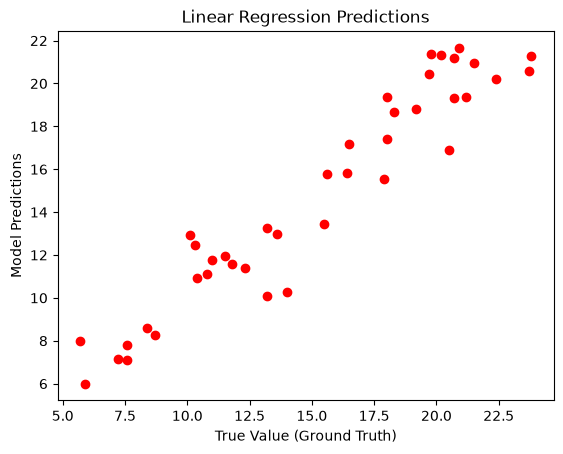

In [19]:
plt.scatter(y_test, y_predict, color = 'r')
plt.ylabel('Model Predictions')
plt.xlabel('True Value (Ground Truth)')
plt.title('Linear Regression Predictions')
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)), '.3f'))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
MAPE = np.mean( np.abs( (y_test - y_predict) / y_test ) ) * 100

In [21]:
print('RMSE =', RMSE, '\nMSE =', MSE, '\nMAE =', MAE, '\nMean Absolute Percentage Error =', MAPE, '%')

RMSE = 1.593 
MSE = 2.5388821630553786 
MAE = 1.1922285453007 
Mean Absolute Percentage Error = 8.294603695406618 %
